# 🌐 第 71 课 · 华为 AI 生态全景:昇腾 + CANN + MindSpore + ModelArts

> 不是一颗芯片,而是一整套『造车产业链』:硬件 → CANN → MindSpore → Lite → 云,看懂昇腾生态全景

**章节**: 第 11 章 · 华为昇腾与 MindSpore 生态

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 看懂昇腾硬件家族:推理卡 Ascend 310/310P 与训练卡 910A/910B 的分工
- 理解 CANN 软件栈在『硬件与框架之间』的使能地位(ACL / GE / 算子层 / Runtime)
- 认识自研框架 MindSpore 的定位、MindSpore Lite 的推理能力与 ModelArts 云上服务
- 画出昇腾『设备层 → CANN → 框架层 → 应用层』的分层全景图(matplotlib)
- 把昇腾生态与 vLLM 的推理路径对接(vllm-ascend / MindIE)

## 📑 本课目录

1. **直觉:一整套 AI 产业链** — 从『一块芯片』到『软硬一体』的完整版图
2. **昇腾硬件家族** — 310 系列做推理、910 系列做训练,算力账算给你看
3. **生态全景分层图** — 设备层 → CANN → 框架层 → 应用层的 matplotlib 结构图
4. **CANN:硬件使能层** — ACL / 图引擎 GE / 算子层 / Runtime 各司其职
5. **MindSpore 与三个生态位** — MindSpore / PyTorch / TensorFlow 的定位雷达图
6. **MindSpore Lite 与 ModelArts** — 端侧推理优化 + 云上训练推理一体化
7. **昇腾 × vLLM** — vllm-ascend 与 MindIE:推理引擎如何落地上昇腾

## 🔗 参考资料

- [昇腾社区官网](https://www.hiascend.com)
- [MindSpore 文档](https://www.mindspore.cn)
- [昇腾 CANN 文档中心](https://www.hiascend.com/document)
- [MindSpore Lite 文档](https://www.mindspore.cn/lite)
- [vllm-ascend(GitHub)](https://github.com/vllm-project/vllm-ascend)

🧊 本课开篇:KMP 保护 + 会议论文风格绘图头(本机无昇腾硬件,全程用 torch + matplotlib 讲真实概念)。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # 避免 OMP 库冲突(Windows)
import time, math
import numpy as np
import pandas as pd
import torch

torch.manual_seed(0)
torch.set_float32_matmul_precision("high")              # 开启 TF32,加速并消除告警
print("torch =", torch.__version__,
      "| CUDA =", torch.cuda.is_available(),
      "| device =", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------- 会议论文风格绘图:matplotlib + seaborn ----------
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 中文
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
print("本机未安装 MindSpore / 无昇腾硬件:全章用 torch + matplotlib 类比讲解真实概念。")

torch = 2.11.0+cu128 | CUDA = True | device = NVIDIA GeForce RTX 5060 Laptop GPU


本机未安装 MindSpore / 无昇腾硬件:全章用 torch + matplotlib 类比讲解真实概念。


## 1️⃣ 直觉:华为想造的是一整套 AI 产业链 🏭

很多人以为昇腾(Ascend)只是"一块 AI 芯片",但华为真正想做的,是把从芯片到应用的
**整条 AI 产业链**都握在手里。用汽车产业来类比:

- **昇腾 310 / 910 芯片** 是发动机(算力核心);
- **Atlas 服务器 / 加速卡** 是把发动机装上车(整机);
- **CANN** 是变速箱与底盘(硬件使能软件栈,让框架能开得动这辆车);
- **MindSpore** 是智能驾驶系统(AI 框架,提供方向盘与仪表盘);
- **MindSpore Lite** 是车载导航(端侧/边缘的轻量推理器);
- **ModelArts** 是云端驾校与 4S 店(云上训练、调优、部署一站式);
- **MindStudio** 是维修手册(IDE 工具链)。

这和 NVIDIA 的路线不同:NVIDIA 卖"发动机 + 变速箱"(芯片 + CUDA),而华为把
"造车、开 4S 店、办驾校"全包了。这也解释了为什么昇腾生态里处处有自己的名字:
自己的芯片、自己的编译器、自己的框架、自己的云。接下来我们从硬件一路往上看。

## 2️⃣ 昇腾硬件家族:推理用 310,训练用 910 🖥️

昇腾芯片按**场景**分两大家族:

- **Ascend 310 系列**:推理 / 边缘场景,功耗低、主打 INT8 算力。常见于 Atlas 300I 推理卡、
  Atlas 200 DK 开发者套件 —— 就像"省油的货车",专门跑已训好的模型;
- **Ascend 910 系列**:训练场景,FP16 / BF16 高算力。常见于 Atlas 800 训练服务器 ——
  就像"大马力的赛车",专门训练大模型。

**关键洞察**:推理卡的指标看 **INT8 TOPS**(低精度、高吞吐),训练卡看 **FP16/BF16 TFLOPS**
(精度与算力兼顾)。下面把算力画出来(数值为公开资料整理的示意量级):

📊 算力对比:910 系列 FP16 达到数百 TFLOPS,是训练 7B/70B 模型的主力;310 系列专注 INT8 推理,功耗低、适合边缘部署。

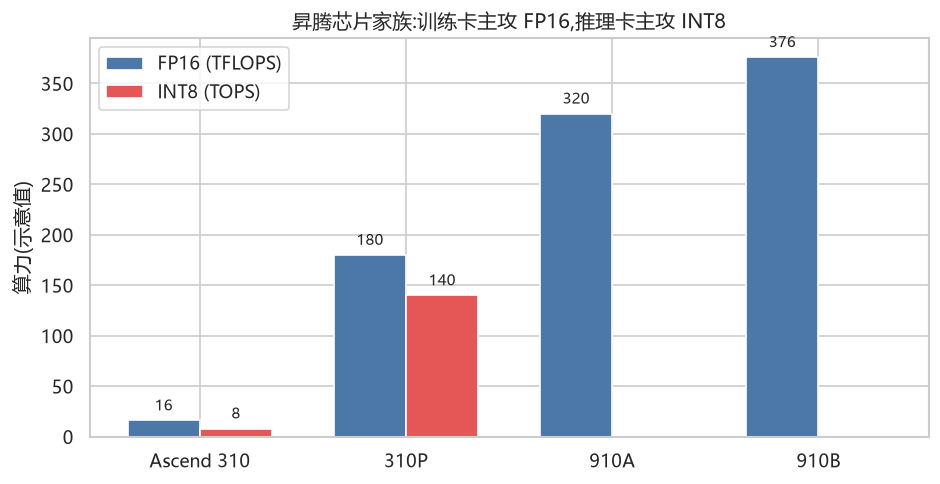

In [2]:
chips = ["Ascend 310", "310P", "910A", "910B"]
fp16 = [16, 180, 320, 376]      # FP16 TFLOPS(示意)
int8 = [8, 140, 0, 0]           # INT8 TOPS(训练卡不主打 INT8)
x = np.arange(len(chips)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4.2))
b1 = ax.bar(x - w/2, fp16, w, label="FP16 (TFLOPS)", color="#4C78A8")
b2 = ax.bar(x + w/2, int8, w, label="INT8 (TOPS)", color="#E45756")
ax.set_xticks(x); ax.set_xticklabels(chips)
ax.set_ylabel("算力(示意值)")
ax.set_title("昇腾芯片家族:训练卡主攻 FP16,推理卡主攻 INT8")
for b in list(b1) + list(b2):
    if b.get_height() > 0:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 10, f"{int(b.get_height()):.0f}",
                ha="center", fontsize=9)
ax.legend(); plt.tight_layout()

## 3️⃣ 生态全景:一张分层架构图看懂全局 🗺️

昇腾生态自底向上可以画成四层:**设备层(芯片/整机)→ 软件使能层(CANN)→ 框架层
(MindSpore/PyTorch)→ 应用层(云、推理引擎、行业应用)**。CANN 是唯一横跨所有框架的
"翻译官"——不管上层是 MindSpore 还是 PyTorch,最终都要通过 CANN 落到昇腾芯片上。
这就是常说的 **『昇腾计算产业』** 分层:

🎨 全景分层图:框架层负责『翻译』,CANN 负责『使能』,设备层负责『执行』。后面 72/73 课把中间两层拆开细看。

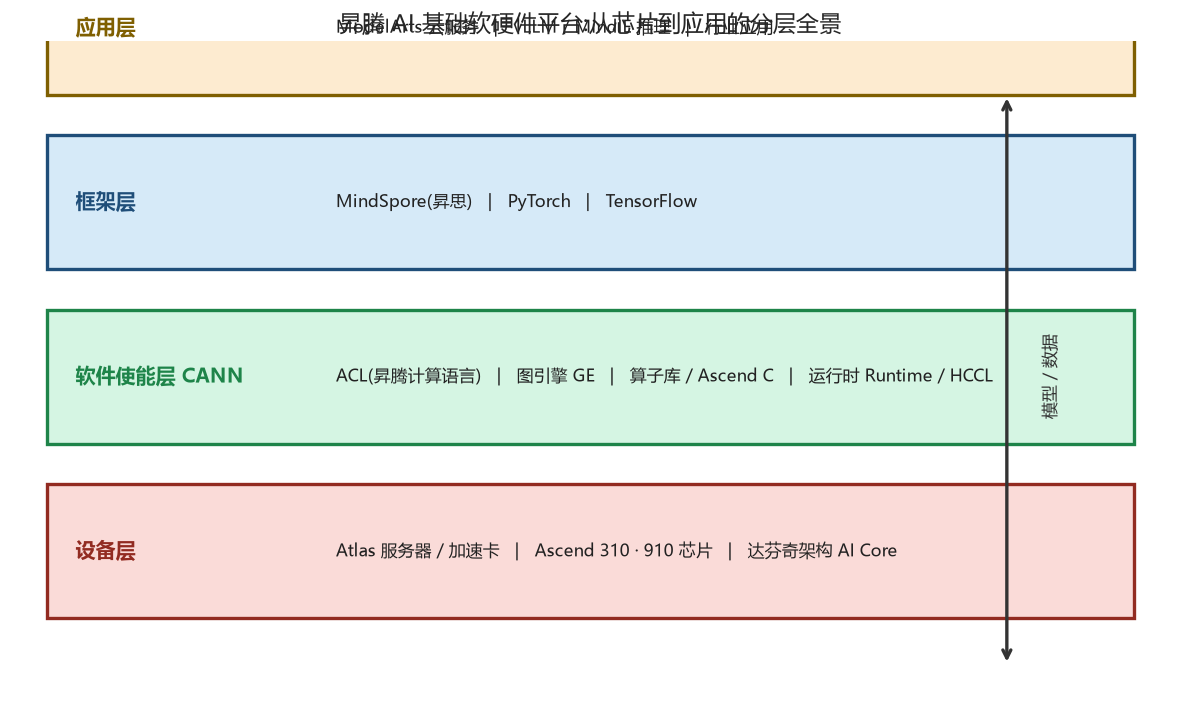

In [3]:
fig, ax = plt.subplots(figsize=(10, 6.2))
ax.axis("off")
layers = [
    ("应用层", ["ModelArts 云服务", "vLLM / MindIE 推理", "行业应用"], "#fdebd0", "#7f5f01"),
    ("框架层", ["MindSpore(昇思)", "PyTorch", "TensorFlow"], "#d6eaf8", "#1f4e79"),
    ("软件使能层 CANN", ["ACL(昇腾计算语言)", "图引擎 GE", "算子库 / Ascend C", "运行时 Runtime / HCCL"], "#d5f5e3", "#1e8449"),
    ("设备层", ["Atlas 服务器 / 加速卡", "Ascend 310 · 910 芯片", "达芬奇架构 AI Core"], "#fadbd8", "#922b21"),
]
y = 4.6
for name, items, color, edge in layers:
    ax.add_patch(plt.Rectangle((0.3, y), 9.4, 1.0, facecolor=color, edgecolor=edge, lw=2))
    ax.text(0.55, y + 0.5, name, ha="left", va="center", fontsize=12, fontweight="bold", color=edge)
    ax.text(2.8, y + 0.5, "   |   ".join(items), ha="left", va="center", fontsize=10, color="#222")
    y -= 1.3
ax.annotate("", xy=(8.6, 4.6), xytext=(8.6, 0.35),
            arrowprops=dict(arrowstyle="<->", lw=2, color="#333"))
ax.text(8.9, 2.5, "模型 / 数据", fontsize=10, rotation=90, va="center", color="#333")
ax.set_xlim(0, 10); ax.set_ylim(0, 5)
ax.set_title("昇腾 AI 基础软硬件平台:从芯片到应用的分层全景", fontsize=14)
plt.tight_layout()

## 4️⃣ CANN:横跨一切的『硬件使能层』 ⚙️

**CANN**(Compute Architecture for Neural Networks)是昇腾的软件中枢,位置非常特殊:
它夹在框架与芯片之间,承担四件事 ——

1. **ACL(昇腾计算语言 / Ascend Computing Language)**:面向应用与推理场景的 C/Python API,
   管设备、管模型加载、管推理执行;
2. **图引擎 GE(Graph Engine)**:拿到框架传下来的计算图,做**图优化、算子融合、整图下沉**,
   把"图"变成"能在芯片上跑的东西";
3. **算子层**:预置算子库 + **Ascend C** 算子开发语言(第 74 课专讲);
4. **运行时 Runtime 与 HCCL**:任务调度、内存管理、多卡集合通信(对标 NCCL)。

一句话:CANN 之于昇腾,就像 **CUDA 之于 NVIDIA**。用热力图看看各组件各管哪摊事:

📊 CANN 组件分工:ACL 管应用与设备,GE 管图优化,算子库 + Ascend C 管『会算』,HCCL 管多卡协作。

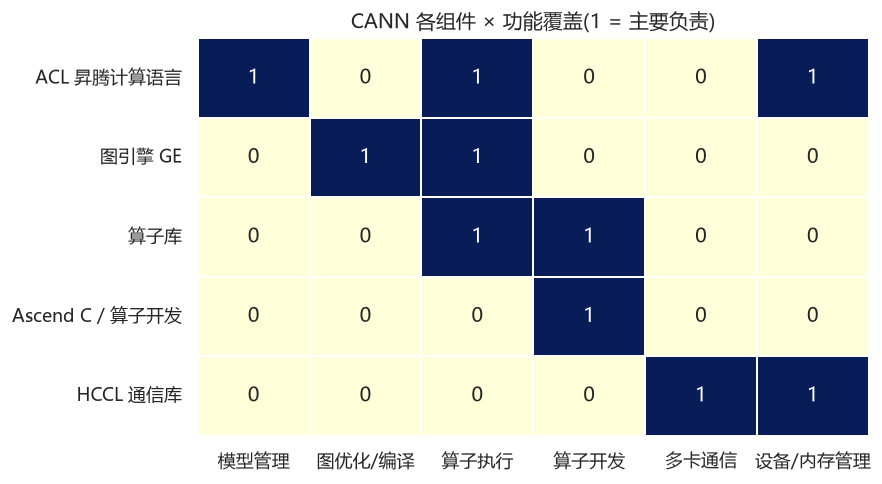

In [4]:
cann_comp = pd.DataFrame({
    "模型管理": [1, 0, 0, 0, 0],
    "图优化/编译": [0, 1, 0, 0, 0],
    "算子执行": [1, 1, 1, 0, 0],
    "算子开发": [0, 0, 1, 1, 0],
    "多卡通信": [0, 0, 0, 0, 1],
    "设备/内存管理": [1, 0, 0, 0, 1],
}, index=["ACL 昇腾计算语言", "图引擎 GE", "算子库", "Ascend C / 算子开发", "HCCL 通信库"])
fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.heatmap(cann_comp, annot=True, fmt="d", cmap="YlGnBu", linewidths=1,
            linecolor="white", cbar=False, ax=ax)
ax.set_title("CANN 各组件 × 功能覆盖(1 = 主要负责)")
plt.tight_layout()

## 5️⃣ MindSpore:华为自研的全场景 AI 框架 🧠

**MindSpore(昇思)** 是华为自研的 AI 框架,号称"全场景":同一个框架,既能跑云端训练,
也能跑端侧、边缘设备,还能通过 **自动并行** 把一个大模型拆到上千张昇腾卡上训。
它的两个标志性能力:

- **双模式**:PyNative(动态图,灵活调试)与 Graph(静态图,性能优先)—— 第 76/77 课专讲;
- **与昇腾深度绑定**:图模式编译出的计算图可以直接**整图下沉**到昇腾执行,绕开逐算子
  调度的开销。

把三大框架放进"定位雷达"里对比,昇腾生态的取舍一目了然:

🎯 雷达图:MindSpore 在『静态图优化 / 自动并行 / 端边云 / 昇腾绑定』全面拉满;PyTorch 赢在生态与动态图易用性。这就是昇腾生态『自主可控』的底气。

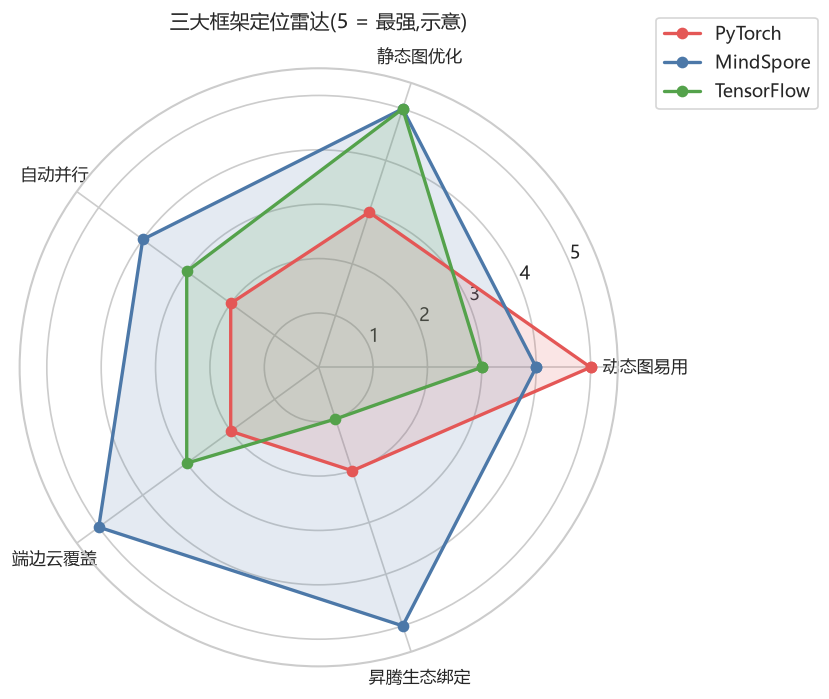

In [5]:
dims = ["动态图易用", "静态图优化", "自动并行", "端边云覆盖", "昇腾生态绑定"]
angles = np.linspace(0, 2 * np.pi, len(dims), endpoint=False).tolist()

def radar(ax, vals, label, color):
    v = vals + vals[:1]; a = angles + angles[:1]
    ax.plot(a, v, "o-", color=color, lw=2, label=label)
    ax.fill(a, v, color=color, alpha=0.15)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, polar=True)
radar(ax, [5, 3, 2, 2, 2], "PyTorch", "#E45756")
radar(ax, [4, 5, 4, 5, 5], "MindSpore", "#4C78A8")
radar(ax, [3, 5, 3, 3, 1], "TensorFlow", "#54A24B")
ax.set_xticks(angles); ax.set_xticklabels(dims, fontsize=10)
ax.set_ylim(0, 5.5)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
ax.set_title("三大框架定位雷达(5 = 最强,示意)", pad=24)
plt.tight_layout()

## 6️⃣ MindSpore Lite 与 ModelArts:推理落地与云上服务 ☁️

大模型训完要部署,华为给出了两条腿:

- **MindSpore Lite**:面向端侧 / 边缘的轻量推理引擎。它把训练好的模型(常用 **MindIR**
  中间表示)做**离线转换与量化优化**,生成体积小、跑得快的推理模型,再部署到手机、
  Atlas 边缘设备上 —— 相当于把"大货车"改装成"小快艇";
- **ModelArts**:华为云的 AI 开发平台,把"数据标注 → 训练 → 调优 → 推理部署"整条流水线
  搬到云上,底层调度的正是昇腾算力集群。就像"云端驾校 + 出租车公司",你只交需求,平台管一切。

用一张交互柱状图看看生态各组件在**训练 / 推理**两个场景里的依赖度:

📈 pyecharts 交互图(可悬停):训练靠 MindSpore 全家桶,推理靠 Lite / MindIE —— 两条腿各有侧重。

In [6]:
from pyecharts.charts import Bar
from pyecharts import options as opts
comps = ["昇腾硬件", "CANN", "MindSpore", "MindSpore Lite", "ModelArts", "MindIE"]
train = [5, 5, 5, 1, 4, 2]      # 训练侧依赖度(示意)
infer = [4, 5, 2, 5, 3, 5]      # 推理侧依赖度(示意)
bar = (Bar()
       .add_xaxis(comps)
       .add_yaxis("训练侧重", train, color="#4C78A8")
       .add_yaxis("推理侧重", infer, color="#E45756")
       .set_global_opts(title_opts=opts.TitleOpts(title="昇腾生态组件:训练 vs 推理的依赖度(示意)"),
                        yaxis_opts=opts.AxisOpts(name="依赖度"),
                        legend_opts=opts.LegendOpts(pos_top="6%")))
bar.render_notebook()

## 7️⃣ 昇腾 × vLLM:推理引擎怎么落地上昇腾 🚀

最后一问:我们这本《VLLM_learn》一直用 vLLM 跑 GPU,昇腾上能不能跑 vLLM?**能**。
生态里有两个关键项目:

- **vllm-ascend**:vLLM 官方支持的昇腾分支,把 vLLM 的推理管线(PagedAttention、连续
  batching、prefix caching 等)映射到昇腾 CANN 上执行;
- **MindIE**:华为自研的推理引擎,专门为昇腾深度优化 LLM 推理(权重内存、KV Cache 管理、
  图算融合等)。

所以昇腾上的 LLM 推理路径是:**模型(ONNX/MindIR)→ CANN 图引擎 GE → 整图下沉 → 昇腾芯片**。
理解这条路径,正是后面 72-80 课要做的事:先看懂芯片(72)→ 软件栈(73)→ 算子(74)→
框架(75-78)→ 图融合(79)→ 分布式(80)。下一课,我们从最底层的**达芬奇架构**开始。

## ✅ 本课小结

- 昇腾是『软硬一体』的 AI 产业链:芯片(310 推理 / 910 训练)→ CANN → MindSpore → Lite/ModelArts
- 推理卡看 INT8 TOPS,训练卡看 FP16/BF16 TFLOPS —— 硬件指标对应各自场景
- CANN 是唯一横跨所有框架的『硬件使能层』:ACL 管应用、GE 管图、算子层管计算、HCCL 管通信
- MindSpore 的定位:全场景 + 双模式 + 自动并行 + 与昇腾深度绑定;Lite 负责端侧推理,ModelArts 负责云
- 昇腾上跑 vLLM 的路径:模型 → CANN 图引擎 → 整图下沉 → 昇腾芯片(vllm-ascend / MindIE)

## ✍️ 动手练习

1. 把分层全景图的『应用层』再拆细:列出你见过的 5 个昇腾上跑的应用/推理引擎(vLLM、MindIE、ATB 等)
2. 给雷达图新增一个维度『开源生态』,给三大框架重新打分,说说昇腾生态的最大短板在哪
3. 查一下 Ascend 910B 与 NVIDIA A100/H100 的 FP16 算力与显存,做一张并排对比表(标注资料年份)
4. 用 pyecharts 给生态组件图新增第三个系列『边缘侧依赖度』,重画柱状图

## 🔗 延伸阅读

- [昇腾社区官网](https://www.hiascend.com)
- [MindSpore 官方文档](https://www.mindspore.cn)
- [vllm-ascend](https://github.com/vllm-project/vllm-ascend)
- [MindSpore Lite 文档](https://www.mindspore.cn/lite)

---
> 🎉 恭喜完成本课!下一课见!